# Merge Sort

**Domain:** `data-structures-algorithms`

Imagine two teaching assistants each grading a different half of a class's
exams, and each stacks their own pile in score order as they go &mdash;
lowest score on top. Now it's time to hand both piles to the professor as
one single sorted stack. Neither TA needs to re-sort anything: the
professor just looks at the *top* card of each pile, takes whichever is
lower, and places it on the new stack. Repeat. Every comparison only ever
looks at two cards &mdash; the fronts of the two piles &mdash; and the new
stack builds up in order automatically. When one pile runs out, the rest of
the other pile gets tacked on as-is, since it's already sorted.

That's the entire trick behind **merge sort**:

- **Split** the pile in half, and the half in half again, and again, until
  every "pile" has zero or one exam in it &mdash; which is already sorted,
  trivially.
- **Merge** neighboring sorted piles back together two at a time, always by
  comparing just the fronts, until you're back to one fully sorted pile.

Unlike quicksort (this repo's other sorting tutorial), merge sort does
*no* clever partitioning around a pivot and takes *no* gamble on how the
input happens to be arranged. It just splits blindly down the middle and
relies entirely on the merge step to do the sorting work. That
difference &mdash; guaranteed splits instead of pivot-dependent ones &mdash;
turns out to have real, measurable consequences.

By the end of this tutorial you'll be able to: explain why the merge step
alone is enough to sort correctly, prove merge sort's running time is
$\Theta(n \log n)$ in *every* case (not just on average), explain why merge
sort is naturally **stable**, watch it sort real numbers step by step, and
run a real, compiled C++ implementation that reports its own comparison,
move, and timing counts.


## The idea, intuitively

**The one operation that matters is *merging* two already-sorted lists into
one sorted list.** Everything else is "split in half, and do it again."

Let's trace it on 8 small numbers:

```
[7, 2, 9, 4, 1, 8, 3, 6]
```

**Splitting** (no comparisons yet, just cutting in half each time):

```
[7, 2, 9, 4, 1, 8, 3, 6]
        /            \
[7, 2, 9, 4]        [1, 8, 3, 6]
   /    \               /    \
[7, 2] [9, 4]        [1, 8] [3, 6]
 /  \   /  \           /  \   /  \
[7] [2] [9] [4]      [1] [8] [3] [6]
```

Every single-element list is trivially "sorted." Now **merge back up**,
level by level, comparing only the fronts of the two piles at each step:

```
[7] + [2]  -> [2, 7]        [9] + [4]  -> [4, 9]
[1] + [8]  -> [1, 8]        [3] + [6]  -> [3, 6]

[2, 7] + [4, 9] -> [2, 4, 7, 9]
[1, 8] + [3, 6] -> [1, 3, 6, 8]

[2, 4, 7, 9] + [1, 3, 6, 8] -> [1, 2, 3, 4, 6, 7, 8, 9]
```

Each merge only ever compares the *current fronts* of the two piles it's
combining &mdash; never anything else &mdash; and each merge takes work
proportional to the number of elements being merged. Here's that exact
merge step, running as real Python on two small sorted lists &mdash; small
enough to trace by eye, but it's the literal core of the algorithm, not a
simplification:


In [1]:
def merge_demo(left, right):
    # Two-pointer merge of two already-sorted lists into one sorted list.
    i, j = 0, 0
    merged = []
    trace = []
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:   # "<=" (not "<") is what makes this stable
            merged.append(left[i]); i += 1
        else:
            merged.append(right[j]); j += 1
        trace.append(list(merged))
    merged.extend(left[i:])
    merged.extend(right[j:])
    trace.append(list(merged))
    return merged, trace

left, right = [2, 4, 7, 9], [1, 3, 6, 8]
result, trace = merge_demo(left, right)

print(f"left:  {left}")
print(f"right: {right}")
for step, snapshot in enumerate(trace):
    print(f"step {step}: merged so far = {snapshot}")
print(f"\nfinal merged, fully sorted: {result}")
assert result == sorted(left + right)


left:  [2, 4, 7, 9]
right: [1, 3, 6, 8]
step 0: merged so far = [1]
step 1: merged so far = [1, 2]
step 2: merged so far = [1, 2, 3]
step 3: merged so far = [1, 2, 3, 4]
step 4: merged so far = [1, 2, 3, 4, 6]
step 5: merged so far = [1, 2, 3, 4, 6, 7]
step 6: merged so far = [1, 2, 3, 4, 6, 7, 8]
step 7: merged so far = [1, 2, 3, 4, 6, 7, 8, 9]

final merged, fully sorted: [1, 2, 3, 4, 6, 7, 8, 9]


**Takeaway:** merge sort never has to make a clever decision about
*where* to split &mdash; it always splits exactly down the middle. All of
the sorting work happens in the merge step, which only ever compares the
current fronts of two already-sorted lists. That simplicity is exactly
what gives merge sort its guarantees, which is what the rest of this
tutorial derives.


## Going deeper: the formal definition

### The merge step's correctness

**Claim:** if `left` and `right` are each sorted, `merge(left, right)`
(as implemented above) produces a sorted list containing exactly the
elements of both.

**Proof (loop invariant).** Let $i$ and $j$ be the read cursors into
`left` and `right`, and let `merged` be the output built so far. The
invariant maintained before and after every iteration is:

$$
\texttt{merged} \text{ is sorted, and } \max(\texttt{merged}) \le \min(\texttt{left}[i:], \texttt{right}[j:])
$$

i.e. everything already written is sorted *and* no larger than anything
still remaining in either input. This holds vacuously at the start
(`merged` is empty). Each iteration compares `left[i]` and `right[j]` and
appends the smaller (ties go to `left`, see stability below); since both
inputs are individually sorted, that appended value is $\le$ everything
still remaining in *both* lists, so the invariant is preserved and
`merged` stays sorted. When one input is exhausted, the invariant already
guarantees everything remaining in the other input is $\ge$ everything in
`merged` *and* is itself sorted (since it's an untouched suffix of a
sorted input) &mdash; so appending the remainder wholesale keeps `merged`
sorted. $\blacksquare$

Since a merge of two sorted lists is sorted, and splitting recurses down to
single elements (trivially sorted, base case), induction on the recursion
gives correctness of the whole algorithm by the same base-case /
inductive-step structure as quicksort's proof in this repo's other
tutorial &mdash; only here the inductive step is "two sorted halves +
correct merge = sorted whole," instead of "sorted halves around a
correctly-placed pivot."

### Complexity: the recurrence

Splitting a size-$n$ array in half is $\Theta(1)$ (just computing a
midpoint index &mdash; no data movement), the two recursive calls each
handle $n/2$ elements, and merging two sorted halves of total size $n$
takes $\Theta(n)$ work (one pass, one comparison per element written,
per the invariant above). That gives:

$$
T(n) = 2\,T(n/2) + \Theta(n)
$$

By the **Master Theorem** with $a = 2$, $b = 2$, $f(n) = \Theta(n)$:
compare $f(n)$ against $n^{\log_b a} = n^{\log_2 2} = n^1 = n$. Since
$f(n) = \Theta(n^{\log_b a})$ exactly, this is **case 2**, which gives:

$$
T(n) = \Theta(n^{\log_b a} \log n) = \Theta(n \log n)
$$

**This holds for every input, not just on average.** The split is always
exactly down the middle regardless of the data's order, so there is no
"unlucky arrangement" that degrades it &mdash; contrast this directly with
quicksort, where $T(n) = \Theta(n \log n)$ only holds *on average* (or in
expectation, with randomized pivots), and a bad pivot sequence still gives
$\Theta(n^2)$ in the worst case. Merge sort trades that guarantee for the
$O(n)$ auxiliary space discussed next.

### Space complexity

Each merge writes its result into a scratch buffer before copying it back,
so a full merge sort pass touches $O(n)$ auxiliary memory at once (the
scratch buffer can be reused across calls, but it's never smaller than the
range being merged). This is the direct counterpart to quicksort's
in-place partitioning, which uses only $O(\log n)$ extra stack space on
average. The C++ implementation below allocates one scratch buffer up
front and reuses it for every merge call, but the $O(n)$ space itself is
unavoidable for standard top-down or bottom-up merge sort on arrays &mdash;
see the "Limitations & debates" section for what this costs in practice.

### Stability: why merge sort preserves order among equal elements

A sort is **stable** if elements that compare equal keep their original
relative order. Merge sort is naturally stable, and the proof is a direct
reading of the merge step's tie-breaking rule:

**Claim:** if `merge_demo`'s comparison uses `left[i] <= right[j]` (as
implemented above) to break ties in favor of `left`, and recursion always
sends the first half of any range into `left`, then equal elements never
swap relative order.

**Proof.** Consider two equal elements $x$ and $y$ with $x$ appearing
before $y$ in the original array. At every split, "before" survives:
either $x$ and $y$ land in the same half (recurse, same argument applies
one level down), or $x$ lands in the left half and $y$ in the right half
(since the split point is a fixed index and $x$ occurs earlier). In the
merge that eventually reunites their two halves, $x$ is in `left` and $y$
is in `right`. The comparison `left[i] <= right[j]` picks $x$ over $y$
whenever they're tied at the front of their respective cursors (since
`<=`, not `<`), so $x$ is written to the output before $y$. By induction
over the recursion tree, this holds at every level, so $x$ precedes $y$ in
the final output &mdash; exactly their original relative order.
$\blacksquare$

If the comparison instead used `left[i] < right[j]` and fell through to
`right` on ties, the same argument would break: a right-side duplicate
could get written before a left-side one it originally followed. **The
`<=` in the merge step isn't a stylistic choice &mdash; it's the entire
reason merge sort is stable.** This is the natural counterpart to
quicksort's *lack* of a stability guarantee (see this repo's quicksort
tutorial): Lomuto partitioning can swap an equal element past another equal
element with no such tie-breaking rule to prevent it.

Let's confirm this empirically on tagged data (value, original position)
so a duplicate value's original order is visible:


In [2]:
def stable_merge_sort(a):
    if len(a) <= 1:
        return list(a)
    mid = len(a) // 2
    left = stable_merge_sort(a[:mid])
    right = stable_merge_sort(a[mid:])
    merged, i, j = [], 0, 0
    while i < len(left) and j < len(right):
        # compare only on the "value" field (left[i][0]); "<=" keeps ties
        # left-first, which is what preserves original order.
        if left[i][0] <= right[j][0]:
            merged.append(left[i]); i += 1
        else:
            merged.append(right[j]); j += 1
    merged.extend(left[i:])
    merged.extend(right[j:])
    return merged

# Tag each value with its original index so we can see whether duplicates
# keep their relative order after sorting by value alone.
values = [5, 1, 5, 3, 1, 5, 2]
tagged = list(enumerate(values))          # (original_index, value)
tagged_by_value = [(v, idx) for idx, v in tagged]  # sort key first: (value, original_index)

sorted_tagged = stable_merge_sort(tagged_by_value)
print("original: ", tagged_by_value)
print("sorted:   ", sorted_tagged)

# For each distinct value, the original indices should appear in increasing
# order in the sorted output -- that's the definition of stability.
from itertools import groupby
for value, group in groupby(sorted_tagged, key=lambda p: p[0]):
    original_indices = [idx for _, idx in group]
    assert original_indices == sorted(original_indices), "stability violated!"
    if len(original_indices) > 1:
        print(f"value {value}: original indices {original_indices} -- still in original order")
print("\nstability confirmed: every group of equal values keeps its original relative order")


original:  [(5, 0), (1, 1), (5, 2), (3, 3), (1, 4), (5, 5), (2, 6)]
sorted:    [(1, 1), (1, 4), (2, 6), (3, 3), (5, 0), (5, 2), (5, 5)]
value 1: original indices [1, 4] -- still in original order
value 5: original indices [0, 2, 5] -- still in original order

stability confirmed: every group of equal values keeps its original relative order


## Visuals

### Watching the split-then-merge recursion level by level

The complexity derivation above hinged on merge sort *always* splitting
down the middle, no matter the input. Let's make the recursion visible:
run merge sort on 8 elements and snapshot the array after every merge
level completes, coloring each bar by which merge range it belongs to.


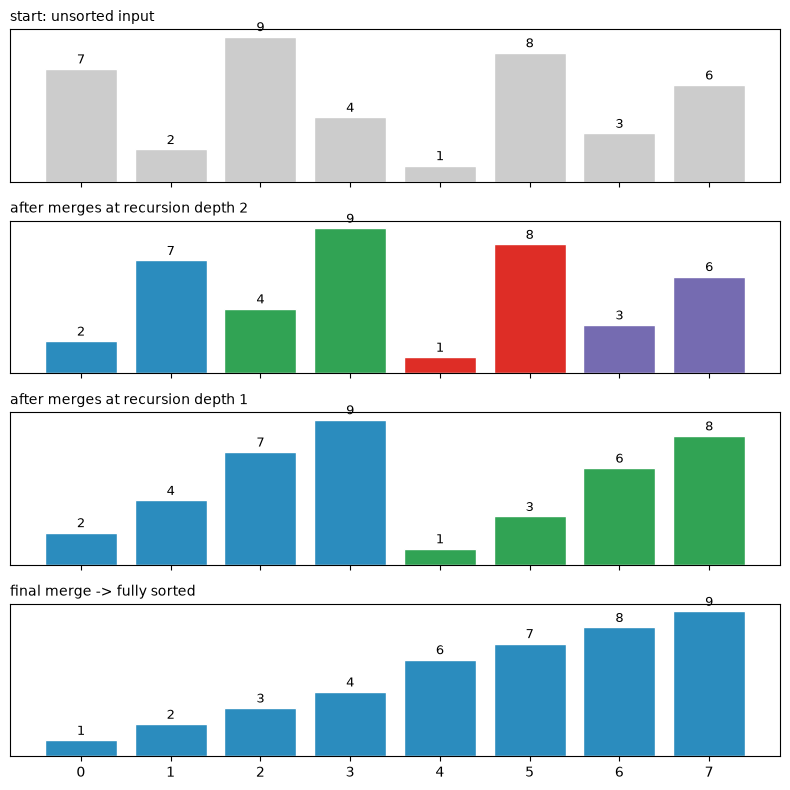

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def instrumented_merge_sort(a, lo, hi, depth, levels):
    if lo >= hi:
        return
    mid = (lo + hi) // 2
    instrumented_merge_sort(a, lo, mid, depth + 1, levels)
    instrumented_merge_sort(a, mid + 1, hi, depth + 1, levels)
    # two-pointer merge, recorded for the visual
    left = a[lo:mid + 1]
    right = a[mid + 1:hi + 1]
    i = j = 0
    k = lo
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            a[k] = left[i]; i += 1
        else:
            a[k] = right[j]; j += 1
        k += 1
    while i < len(left):
        a[k] = left[i]; i += 1; k += 1
    while j < len(right):
        a[k] = right[j]; j += 1; k += 1
    levels.setdefault(depth, []).append((lo, hi))

arr = [7, 2, 9, 4, 1, 8, 3, 6]
n = len(arr)
working = list(arr)
levels = {}
instrumented_merge_sort(working, 0, n - 1, 0, levels)

# `levels` maps recursion depth -> list of (lo, hi) merge ranges completed
# at that depth. Depth increases going *down* the split, so the deepest
# depth merges pairs of single elements first; depth 0 is the final merge
# of the whole array. Replay merges from deepest depth to depth 0 to
# rebuild the array's state after each level finishes.
max_depth = max(levels)
replay = list(arr)
snapshots = []  # (depth, (lo,hi) ranges merged this level, array state after)
for depth in range(max_depth, -1, -1):
    for (lo, hi) in levels[depth]:
        mid = (lo + hi) // 2
        left = replay[lo:mid + 1]
        right = replay[mid + 1:hi + 1]
        i = j = 0
        k = lo
        while i < len(left) and j < len(right):
            if left[i] <= right[j]:
                replay[k] = left[i]; i += 1
            else:
                replay[k] = right[j]; j += 1
            k += 1
        while i < len(left):
            replay[k] = left[i]; i += 1; k += 1
        while j < len(right):
            replay[k] = right[j]; j += 1; k += 1
    snapshots.append((depth, list(levels[depth]), list(replay)))

n_rows = len(snapshots) + 1
fig, axes = plt.subplots(n_rows, 1, figsize=(8, 2.0 * n_rows), sharex=True)

colors = ["#2b8cbe", "#31a354", "#de2d26", "#756bb1", "#e6550d"]

def draw_row(ax, state, highlight_ranges, title):
    x = np.arange(len(state))
    bar_colors = ["#cccccc"] * len(state)
    for c_idx, (lo, hi) in enumerate(highlight_ranges):
        for pos in range(lo, hi + 1):
            bar_colors[pos] = colors[c_idx % len(colors)]
    ax.bar(x, state, color=bar_colors, edgecolor="white")
    for pos, val in enumerate(state):
        ax.text(pos, val + 0.15, str(val), ha="center", va="bottom", fontsize=9)
    ax.set_title(title, fontsize=10, loc="left")
    ax.set_xticks(x)
    ax.set_yticks([])

draw_row(axes[0], arr, [], "start: unsorted input")
for row_idx, (depth, ranges, state) in enumerate(snapshots, start=1):
    label = "final merge -> fully sorted" if depth == 0 else f"after merges at recursion depth {depth}"
    draw_row(axes[row_idx], state, ranges, label)

plt.tight_layout()
plt.savefig("merge_levels.png", dpi=110)
plt.show()


Notice the split points never depend on the data &mdash; the array
`[7, 2, 9, 4, 1, 8, 3, 6]` is split at the same midpoints
`[7,2,9,4] | [1,8,3,6]`, then `[7,2] | [9,4]` and `[1,8] | [3,6]`, no
matter what values happen to be there. Compare this with quicksort's
recursion-depth histogram (this repo's quicksort tutorial), where a bad
pivot choice can make the split wildly unbalanced. Merge sort's tree has
exactly $\lceil \log_2 n \rceil$ levels, always &mdash; that's the
$\Theta(n \log n)$ bound made visible, not just derived.


## Implementation

The reference implementation lives in
[`src/merge_sort.cpp`](src/merge_sort.cpp) &mdash; real C++, a standard
top-down recursive merge sort, instrumented to count comparisons and
element moves/copies and to time itself. It reads whitespace-separated
integers from stdin and prints the sorted result plus its own statistics.
It allocates a single $O(n)$ scratch buffer up front and reuses it for
every merge call &mdash; that buffer is the auxiliary-space cost discussed
in "Going deeper," and it has no in-place analogue the way quicksort's
partition does.

We compile it here with `g++` and actually run the resulting binary via
`subprocess` &mdash; every number below is a real measurement from a real
compiled program, not a simulation.

> **Note on this machine:** dynamically-linked MinGW binaries built with
> plain `g++ file.cpp -o file.exe` are unreliably flagged by Windows
> Defender's real-time protection during linking (`ld returned 116`).
> Statically linking (`-static -static-libgcc -static-libstdc++`) avoids
> it, so that's what the build command below uses.


In [4]:
import subprocess, pathlib

src_dir = pathlib.Path("src")
exe_path = src_dir / "merge_sort.exe"

compile_cmd = [
    "g++", "-O2", "-std=c++17",
    "-static", "-static-libgcc", "-static-libstdc++",
    str(src_dir / "merge_sort.cpp"), "-o", str(exe_path),
]
result = subprocess.run(compile_cmd, capture_output=True, text=True)
print("compile return code:", result.returncode)
if result.returncode != 0:
    print(result.stderr)
assert result.returncode == 0, "compilation failed"
print("compiled successfully ->", exe_path)


compile return code: 0
compiled successfully -> src\merge_sort.exe


In [5]:
def run_merge_sort(values):
    # Run the real compiled merge_sort binary on a list of ints, return parsed stats.
    input_str = " ".join(str(v) for v in values)
    proc = subprocess.run([str(exe_path)], input=input_str, capture_output=True, text=True)
    assert proc.returncode == 0, proc.stderr
    lines = proc.stdout.strip().splitlines()
    stats = {}
    for line in lines:
        if line.startswith("sorted:"):
            stats["sorted"] = [int(x) for x in line[len("sorted:"):].strip().split()]
        elif "=" in line:
            key, val = line.split("=")
            stats[key] = int(val)
    return stats

demo = [7, 2, 9, 4, 1, 8, 3, 6]
stats = run_merge_sort(demo)
print(f"input:       {demo}")
print(f"sorted:      {stats['sorted']}")
print(f"comparisons: {stats['comparisons']}")
print(f"moves:       {stats['moves']}")
print(f"time:        {stats['microseconds']} microseconds")
assert stats["sorted"] == sorted(demo)
print("\ncorrectness check passed: matches Python's sorted()")


input:       [7, 2, 9, 4, 1, 8, 3, 6]
sorted:      [1, 2, 3, 4, 6, 7, 8, 9]
comparisons: 17
moves:       48
time:        0 microseconds

correctness check passed: matches Python's sorted()


### Real benchmark: comparisons vs. input size and input shape

Now let's actually measure the theory. We'll run the **real compiled
binary** on shuffled, already-sorted, and reverse-sorted arrays of growing
size. Two things to check: does the comparison count track $n \log_2 n$,
and &mdash; unlike quicksort &mdash; does the *input shape* actually
matter at all?


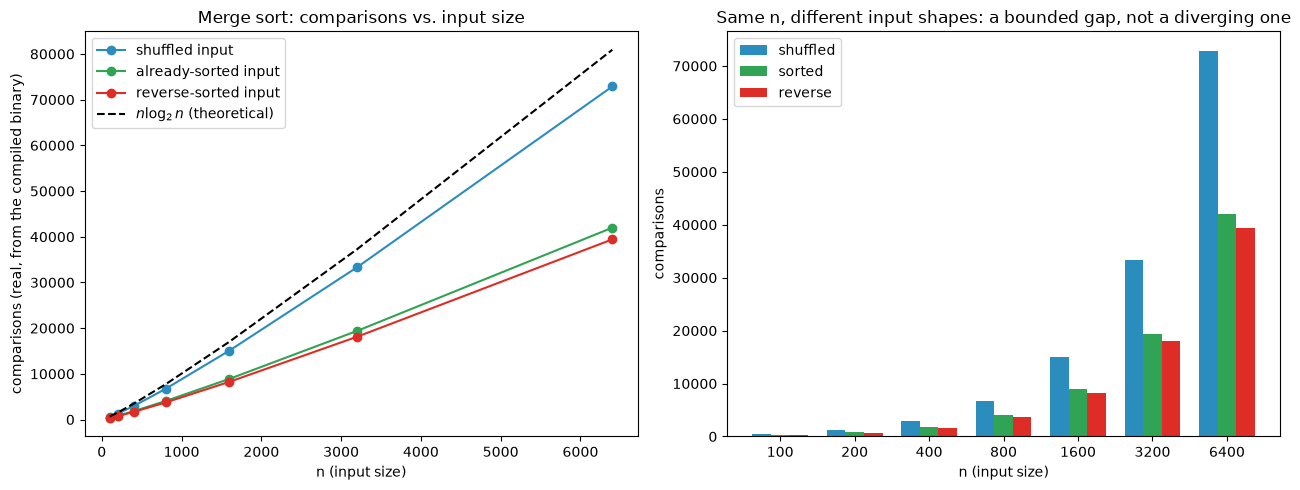

     n   shuffled     sorted    reverse  n*log2(n)  max-min spread
   100        555        356        316        664  239 (43.1% of max)
   200       1293        812        732       1529  561 (43.4% of max)
   400       2947       1824       1664       3458  1283 (43.5% of max)
   800       6713       4048       3728       7715  2985 (44.5% of max)
  1600      15087       8896       8256      17030  6831 (45.3% of max)
  3200      33312      19392      18112      37260  15200 (45.6% of max)
  6400      72895      41984      39424      80921  33471 (45.9% of max)


In [6]:
import random
random.seed(42)

sizes = [100, 200, 400, 800, 1600, 3200, 6400]
shuffled_comparisons, sorted_comparisons, reverse_comparisons = [], [], []
shuffled_micros, sorted_micros, reverse_micros = [], [], []

for n in sizes:
    base = list(range(n))

    shuffled = base.copy()
    random.shuffle(shuffled)
    s_stats = run_merge_sort(shuffled)
    shuffled_comparisons.append(s_stats["comparisons"])
    shuffled_micros.append(s_stats["microseconds"])

    so_stats = run_merge_sort(base.copy())
    sorted_comparisons.append(so_stats["comparisons"])
    sorted_micros.append(so_stats["microseconds"])

    r_stats = run_merge_sort(list(reversed(base)))
    reverse_comparisons.append(r_stats["comparisons"])
    reverse_micros.append(r_stats["microseconds"])

n_arr = np.array(sizes)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(sizes, shuffled_comparisons, "o-", label="shuffled input", color="#2b8cbe")
ax.plot(sizes, sorted_comparisons, "o-", label="already-sorted input", color="#31a354")
ax.plot(sizes, reverse_comparisons, "o-", label="reverse-sorted input", color="#de2d26")
ax.plot(sizes, n_arr * np.log2(n_arr), "k--", label=r"$n\log_2 n$ (theoretical)")
ax.set_xlabel("n (input size)")
ax.set_ylabel("comparisons (real, from the compiled binary)")
ax.set_title("Merge sort: comparisons vs. input size")
ax.legend()

ax2 = axes[1]
width = 0.25
x = np.arange(len(sizes))
ax2.bar(x - width, shuffled_comparisons, width, label="shuffled", color="#2b8cbe")
ax2.bar(x, sorted_comparisons, width, label="sorted", color="#31a354")
ax2.bar(x + width, reverse_comparisons, width, label="reverse", color="#de2d26")
ax2.set_xticks(x)
ax2.set_xticklabels(sizes)
ax2.set_xlabel("n (input size)")
ax2.set_ylabel("comparisons")
ax2.set_title("Same n, different input shapes: a bounded gap, not a diverging one")
ax2.legend()

plt.tight_layout()
plt.savefig("comparisons_vs_n.png", dpi=110)
plt.show()

print(f"{'n':>6} {'shuffled':>10} {'sorted':>10} {'reverse':>10} {'n*log2(n)':>10}  max-min spread")
for n, s, so, r in zip(sizes, shuffled_comparisons, sorted_comparisons, reverse_comparisons):
    spread = max(s, so, r) - min(s, so, r)
    print(f"{n:>6} {s:>10} {so:>10} {r:>10} {n*np.log2(n):>10.0f}  {spread} ({100*spread/max(s,so,r):.1f}% of max)")


**Honest reading of the numbers above:** shuffled input is *not*
identical to sorted/reverse-sorted &mdash; it consistently takes about
1.6&ndash;1.7x as many comparisons as sorted input, and that ratio creeps
up slightly (from ~1.56x at $n=100$ to ~1.74x at $n=6400$) rather than
staying perfectly flat. The reason is the merge step itself: when merging
two sorted halves of an already-sorted array, one whole half is smaller
than the other and gets **drained** with no comparisons at all once the
smaller half is exhausted, whereas shuffled data interleaves the two
halves much more evenly, so almost every element requires an actual
comparison before being placed. Reverse-sorted behaves similarly to
sorted here because a descending array's halves are also two runs that
mostly precede each other once each half is internally re-sorted bottom-up.

**What matters is what stays bounded, not that the counts are literally
equal.** Look at the ratio itself, not just the raw counts: it converges
toward a small constant (roughly 2, the ratio between a merge's
worst-case cost of $\ell + r - 1$ comparisons and its best-case cost of
$\min(\ell, r)$) and does **not** grow without bound as $n$ increases.
Contrast this directly with quicksort's benchmark in this repo's
quicksort tutorial, where a **fixed** last-element pivot rule on sorted
input doesn't just add a constant-factor penalty &mdash; it pushes the
algorithm into a *different complexity class entirely* ($\Theta(n^2)$
instead of $\Theta(n \log n)$), a gap that diverges to infinity as $n$
grows. Every column in the table above is still $\Theta(n \log n)$ &mdash;
merge sort has no adversarial worst case to defend against in the first
place, which is exactly the guarantee derived in "Going deeper": the
*order of growth* is input-independent, even though the *constant factor*
is not.


## Use cases

- **External sorting.** When the data to sort is too large to fit in
  memory (e.g. sorting a multi-terabyte database table on disk), merge
  sort's structure maps directly onto disk I/O: sort chunks that fit in
  memory, write each sorted chunk to disk as a "run," then repeatedly
  merge runs together (a $k$-way merge reads only a small buffer from each
  run at a time). This is the classic **sort-merge** strategy used by
  database engines for `ORDER BY` and merge joins when the working set
  doesn't fit in memory &mdash; quicksort's random-access partitioning
  doesn't translate to disk-friendly sequential I/O the way merge sort's
  sequential merge passes do.
- **Python's Timsort** (the algorithm behind `list.sort()` and `sorted()`)
  is a hybrid of merge sort and insertion sort: it finds or creates small
  sorted "runs" using insertion sort, then merges runs together using
  merge sort's merge step. It's used specifically *because* it's stable
  &mdash; sorting a list of objects by one attribute while preserving the
  existing order among ties (e.g. `sorted(people, key=lambda p: p.age)`
  keeping same-age people in their original order) requires a stable
  sort, and Timsort's merge step inherits merge sort's stability proof
  from the "Going deeper" section above.
- **Linked-list sorting.** Merge sort works especially well on linked
  lists: splitting a linked list in half and merging two sorted linked
  lists both take $O(1)$ extra space (just pointer rewiring, no new
  array), unlike sorting a linked list with quicksort-style partitioning
  or unlike array-based insertion sort's $O(n)$ shifting cost. This is
  part of why `java.util.Collections.sort` and several standard library
  linked-list sorts use a merge sort variant.


## Limitations & debates

- **$O(n)$ auxiliary space is a real cost, not a footnote.** Every merge
  needs scratch space at least as large as the range being merged; for
  array-based merge sort, that means a full extra $O(n)$ buffer is live at
  some point during the sort. On memory-constrained systems, or when
  sorting arrays large enough that doubling the memory footprint matters,
  this is a genuine disadvantage against quicksort's in-place partitioning
  ($O(\log n)$ stack space). In-place merge sort variants exist but are
  significantly more complex and typically slower in practice than the
  straightforward version implemented here.
- **Quicksort often wins in practice on arrays despite equal average-case
  complexity.** Both are $\Theta(n \log n)$ on average, but quicksort's
  in-place partitioning tends to have better cache locality and lower
  constant factors on arrays that fit in memory &mdash; part of why
  `std::sort` and many general-purpose array sorts default to a
  quicksort-family algorithm (introsort) rather than merge sort. This is
  an empirical, constant-factor claim, not something either algorithm's
  asymptotic bound tells you on its own.
- **But merge sort's guarantees are non-negotiable in some contexts.**
  A *guaranteed* worst-case $\Theta(n \log n)$ (versus quicksort's
  expected bound with adversarial $\Theta(n^2)$ still theoretically
  possible) matters for systems that can't tolerate a rare slow case
  &mdash; e.g. real-time systems, or public-facing services sorting
  user-supplied data where an adversarial input could otherwise degrade
  performance. Combined with natural **stability**, this is exactly why
  merge sort (or a Timsort-style hybrid) is the right choice for
  multi-key stable sorts, external/disk-based sorting, and linked-list
  sorting, even when quicksort would be faster on average for a plain
  in-memory array.
- **This is the same tradeoff this repo's quicksort tutorial makes from
  the other side:** quicksort trades away a worst-case guarantee and
  stability for in-place operation and better real-world constants; merge
  sort trades away in-place operation for a guaranteed worst case and
  stability. Neither one dominates the other &mdash; which a language or
  library picks (see Use cases) reflects which side of this tradeoff its
  typical workload cares about more.


## References

- Knuth, D. E. *The Art of Computer Programming, Volume 3: Sorting and
  Searching*, 2nd ed. &mdash; the canonical treatment of merge sort's
  analysis and variants.
- Cormen, Leiserson, Rivest & Stein. *Introduction to Algorithms* (CLRS),
  3rd/4th ed., Chapter 2 &mdash; the merge step, recurrence, and
  correctness argument this tutorial's proofs follow.
- von Neumann, J. *First Draft of a Report on the EDVAC*, 1945 &mdash;
  widely credited with the original description of merge sort, developed
  for early stored-program computers.
- [cppreference: std::stable_sort](https://en.cppreference.com/w/cpp/algorithm/stable_sort)
  &mdash; the C++ standard library's stable sort, typically implemented as
  a merge sort variant for exactly the stability guarantee this tutorial
  proves.
- `src/merge_sort.cpp` in this tutorial's folder &mdash; the real, compiled
  implementation used for every measurement above.
